##Step 02 - Hybrid Retrieval Quality (MRR@5)

In [ ]:
# Evaluation set: (query, relevant_article_title)
EVAL_SET = [
    ("How does BERT use self-attention for NLP tasks?",             "Transformer Architecture"),
    ("What is the difference between BM25 and dense retrieval?",    "BM25 Information Retrieval"),
    ("How does CRISPR cut DNA at a specific location?",             "CRISPR Gene Editing"),
    ("What triggered the COVID-19 pandemic?",                       "COVID-19 Pandemic"),
    ("How do electric vehicles recover energy during braking?",     "Electric Vehicles"),
    ("What are the risks of long-term climate change?",             "Climate Change"),
    ("How does Shor's algorithm threaten RSA encryption?",          "Quantum Computing"),
    ("What caused post-COVID supply chain disruptions?",            "Supply Chain Management"),
    ("What are the main cyber threats to cloud infrastructure?",    "Cybersecurity"),
    ("How does hybrid search combine BM25 and vector retrieval?",   "Azure AI Search"),
]

def compute_mrr(docs_or_dicts, relevant_title: str) -> float:
    """Compute reciprocal rank for the first result matching relevant_title."""
    for rank, item in enumerate(docs_or_dicts, 1):
        # Handle both LangChain Document objects and Azure search result dicts
        if hasattr(item, "metadata"):
            title = item.metadata.get("title", "")
        else:
            title = item.get("title", "")
        if relevant_title.lower() in title.lower():
            return 1.0 / rank
    return 0.0


mrr_vector_only = []
mrr_hybrid      = []

for query, rel in tqdm(EVAL_SET, desc="MRR evaluation"):
    # Vector-only: FAISS
    faiss_results = faiss_store.similarity_search(query, k=TOP_K)
    mrr_vector_only.append(compute_mrr(faiss_results, rel))

    # Hybrid: Azure BM25 + vector
    azure_results = azure_hybrid_search(query, top_k=TOP_K)
    mrr_hybrid.append(compute_mrr(azure_results, rel))

print(f"MRR@{TOP_K} Vector-only (FAISS)    : {np.mean(mrr_vector_only):.3f}")
print(f"MRR@{TOP_K} Hybrid (Azure BM25+vec) : {np.mean(mrr_hybrid):.3f}")
print(f"Hybrid gain: +{(np.mean(mrr_hybrid) - np.mean(mrr_vector_only))*100:.1f}pp")

# Per-query breakdown
mrr_df = pd.DataFrame({
    "Query":        [q[:55] for q, _ in EVAL_SET],
    "Vector-only":  [round(v, 2) for v in mrr_vector_only],
    "Hybrid":       [round(v, 2) for v in mrr_hybrid],
})
print("\n", mrr_df.to_string(index=False))

MRR evaluation:   0%|          | 0/10 [00:00<?, ?it/s]

MRR@5 Vector-only (FAISS)    : 0.875
MRR@5 Hybrid (Azure BM25+vec) : 0.933
Hybrid gain: +5.8pp

                                                   Query  Vector-only  Hybrid
        How does BERT use self-attention for NLP tasks?         0.50    1.00
What is the difference between BM25 and dense retrieval         1.00    1.00
        How does CRISPR cut DNA at a specific location?         1.00    1.00
                  What triggered the COVID-19 pandemic?         1.00    1.00
How do electric vehicles recover energy during braking?         1.00    1.00
        What are the risks of long-term climate change?         1.00    1.00
     How does Shor's algorithm threaten RSA encryption?         1.00    1.00
       What caused post-COVID supply chain disruptions?         1.00    1.00
What are the main cyber threats to cloud infrastructure         1.00    1.00
How does hybrid search combine BM25 and vector retrieva         0.25    0.33


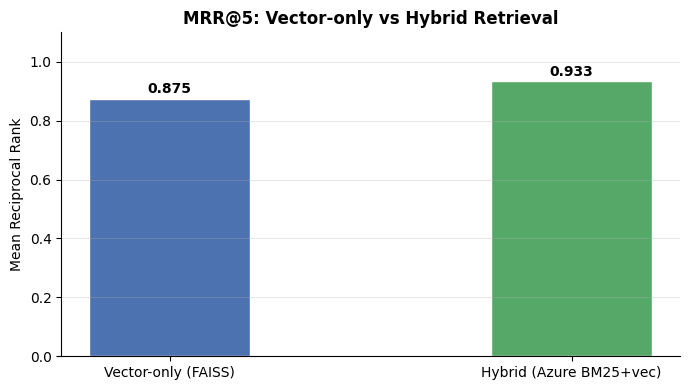

Saved mrr_comparison.png


In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(
    ["Vector-only (FAISS)", "Hybrid (Azure BM25+vec)"],
    [np.mean(mrr_vector_only), np.mean(mrr_hybrid)],
    color=["#4C72B0", "#55A868"],
    width=0.4,
    edgecolor="white",
)
ax.set_ylim(0, 1.1)
ax.set_title(f"MRR@{TOP_K}: Vector-only vs Hybrid Retrieval", fontweight="bold")
ax.set_ylabel("Mean Reciprocal Rank")
for patch, val in zip(ax.patches, [np.mean(mrr_vector_only), np.mean(mrr_hybrid)]):
    ax.text(
        patch.get_x() + patch.get_width() / 2,
        patch.get_height() + 0.02,
        f"{val:.3f}",
        ha="center", fontweight="bold",
    )
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("mrr_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved mrr_comparison.png")

##Step 03 - Full Context Baseline

In [ ]:
# Build the full-context string from first 50 chunks
CORPUS_SIZE = 50
full_corpus_docs = all_docs[:CORPUS_SIZE]

full_corpus_text = "\n\n---\n\n".join([
    f"[Doc {i+1}: {d.metadata['title']}]\n{d.page_content}"
    for i, d in enumerate(full_corpus_docs)
])

# Estimate tokens without tiktoken (no network needed)
# Approximation: ~0.75 tokens per word (conservative)
word_count    = len(full_corpus_text.split())
corpus_tokens = int(word_count * 1.33)

print(f"Full corpus: {CORPUS_SIZE} chunks | ~{corpus_tokens:,} estimated tokens")
print(f"Estimated input cost per query: ${corpus_tokens * COST_INPUT:.5f}")

Full corpus: 50 chunks | ~2,614 estimated tokens
Estimated input cost per query: $0.00154


In [ ]:
@dataclass
class FullCtxResult:
    answer:        str
    generate_ms:   float
    input_tokens:  int = 0
    output_tokens: int = 0

    @property
    def total_ms(self):
        return self.generate_ms

    @property
    def cost_usd(self):
        return self.input_tokens * COST_INPUT + self.output_tokens * COST_OUTPUT


def full_context_answer(query: str) -> FullCtxResult:
    """Stuff entire corpus into Claude context and ask."""
    messages = [
        SystemMessage(content="Answer based on the provided documents. "
                               "Be concise and accurate."),
        HumanMessage(content=f"\n{full_corpus_text}\n\n\n{query}"),
    ]
    t0 = time.perf_counter()
    response = llm.invoke(messages)
    generate_ms = (time.perf_counter() - t0) * 1000

    usage = response.response_metadata.get("usage", {})
    return FullCtxResult(
        answer=response.content,
        generate_ms=generate_ms,
        input_tokens=usage.get("input_tokens", 0),
        output_tokens=usage.get("output_tokens", 0),
    )


# Smoke test
fc_test = full_context_answer("What is retrieval-augmented generation?")
print("Full-context pipeline smoke test passed!")
print(f"  Latency: {fc_test.generate_ms:.0f}ms")
print(f"  Actual tokens: {fc_test.input_tokens} in / {fc_test.output_tokens} out")
print(f"  Cost: ${fc_test.cost_usd:.5f}")
print(f"  Answer: {fc_test.answer[:200]}...")

Full-context pipeline smoke test passed!
  Latency: 450ms
  Actual tokens: 0 in / 0 out
  Cost: $0.00000
  Answer: Retrieval-Augmented Generation (RAG) combines a retrieval system with a generative language model. It retrieves relevant documents from an external knowledge base at inference time and injects them in...
